In [34]:
from osa import OSA
import time
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import wshelper as wsh
from wsapi import *  # if necessary
import calibration

# Define Gaussian signal generator outside the function

def gaussian(mu, peak, phase, sigma):
    return lambda x: (peak * np.exp(-(x - mu)**2 / (2 * sigma**2)), phase)

def create_connect_waveshaper():
    wsh.createWS('./WS200224_4x16.wsconfig')
    wsh.connect()

def disconnect_delete_waveshaper():
    wsh.disconnect()
    wsh.deleteWS()

def apply_waveshaper_profile(comblines, peaks, phases, channels, delta_l=0.02, sigma=0.7):
    """
    Function to apply a waveshaper profile based on the input parameters.

    Parameters:
    - comblines: List of center frequencies for the Gaussian signals.
    - peaks: List of peak amplitudes for the Gaussian signals.
    - phases: List of phases for the Gaussian signals.
    - channels: List of channel assignments for each signal.
    - delta_l: Offset for frequency range. Default is 0.4.
    - sigma: Standard deviation for Gaussian function. Default is 0.008.
    """
    
    # Precompute THz values for comblines
    combline_thz = [wsh.nm2thz(combline) for combline in comblines]
    
    # Precompute bounds for each combline
    rang_min = [wsh.nm2thz(combline - delta_l) for combline in comblines]
    rang_max = [wsh.nm2thz(combline + delta_l) for combline in comblines]
    
    # Step 2: Calculate the overall frequency range in THz only once
    rang = (wsh.nm2thz(min(comblines)-0.2), wsh.nm2thz(max(comblines)+0.2))
    rang = (round(rang[0], 3), round(rang[1], 3))

    # Step 3: Generate the signal profile for each combline
    signal = tuple(
        wsh.BoundFunc(
            gaussian(mu=comb_thz, peak=peak, phase=phase, sigma=sigma),
            max_r, min_r, channel
        )
        for comb_thz, peak, phase, channel, min_r, max_r 
        in zip(combline_thz, peaks, phases, channels, rang_min, rang_max)
    )

    # Step 4: Compose the profile
    new_profile = wsh.compose_func((0, 0, 0), rang[1], rang[0], 1e-3, *signal)

    # Step 5: Plot the generated attenuation profile
    plt.plot(wsh.nm2thz(new_profile[:, 0]), -new_profile[:, 1])
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Attenuation')
    plt.title('Generated Profile')
    plt.show()

    # Step 6: Apply profile to waveshaper    
    wsh.apply_profile(new_profile)

def perform_measurement_OSA(osa, center, span, level):
    # === Set the measurement parameters ===
    osa.set_measurement_parameters(center_wavelength = f"{center}nm", span = f"{span}nm", sensitivity = "high1", spacing = "lin", level = level, resolution = 0.02)

    # === Sweep execute ===
    osa.perform_sweep()

    # === Analysis ===
    dbl_mean_wl, dbl_spec_wd = osa.analyze_spectrum()
    print(f"MEAN WL: {dbl_mean_wl * 1e9:.2f} nm")
    print(f"SPEC WD: {dbl_spec_wd * 1e9:.2f} nm")

    wavelengths, power = osa.plot_trace()

    return wavelengths, power


192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   success
Connecting to waveshaper...   waveshaper not found


c:\Users\dalop\OneDrive - stevens.edu\Stevens - PhD Physics\Research\Training 2. Waveshaper AI\Implementation\wshelper.py:103: RuntimeWarning: divide by zero encountered in log10
  return np.log10(ln) * 10


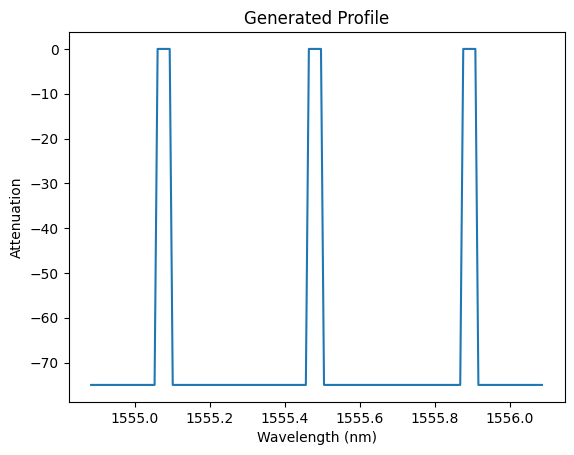

Applying profile...   waveshaper not found
Sweep complete.
MEAN WL: 1555.49 nm
SPEC WD: 1.63 nm


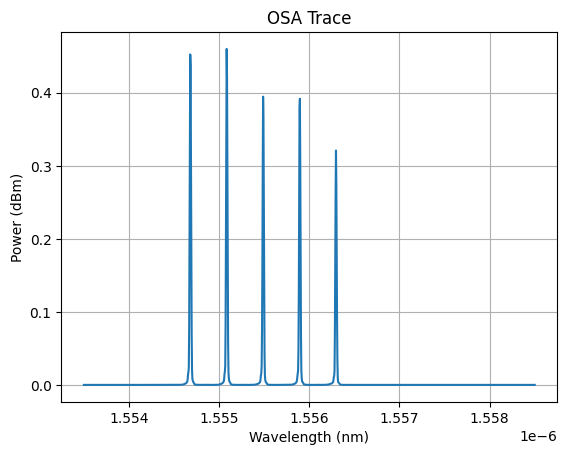

Disconnecting from waveshaper...   success
Deliting waveshaper...   success
Connection closed


In [41]:
# Instantiate and connect OSA
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()

# === Authentication ===
response = osa.autenticate()

# Example of how to call the function
#comblines = [1541, 1542, 1543, 1544, 1545, 1546]

#comblines = [1549.6, 1549.8, 1550, 1550.2, 1550.4, 1550.6]

#comblines =  [1555.6, 1556.0, 1556.4]#[1549.2, 1549.6, 1550]#,
comblines =  [1555.08, 1555.48, 1555.89]#[1549.2, 1549.6, 1550]#,
peaks = [1, 1, 1]#, 1, 1, 1]
phases = [0, 0, 0]#, 0.0, 0.0, 0.0]
channels = [1, 1, 1]#, 1, 1, 1]

create_connect_waveshaper()
apply_waveshaper_profile(comblines, peaks, phases, channels)

if response == 1:
    perform_measurement_OSA(osa, center=1556.0, span=5, level=300)
    #perform_measurement_OSA(osa, center=774.8, span=0.6)

# === Disconnect ===
disconnect_delete_waveshaper()
osa.close_connection()

In [39]:
from osa import OSA
# Instantiate and connect OSA
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()

# === Authentication ===
response = osa.autenticate()

192.168.10.85 is reachable, Connected to OSA
Successfully login!


Sweep complete.
MEAN WL: 777.78 nm
SPEC WD: 0.13 nm


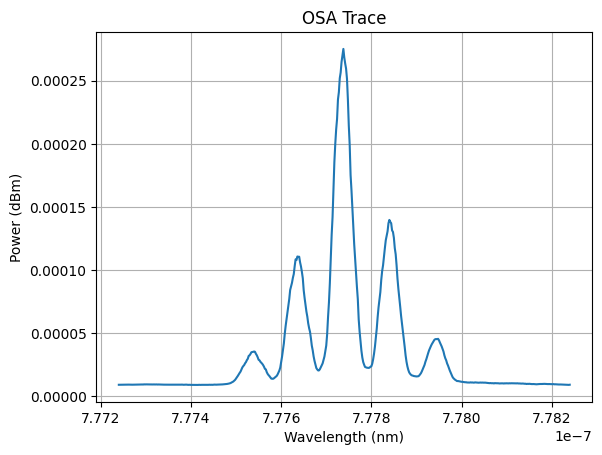

([7.7724e-07,
  7.77242e-07,
  7.77244e-07,
  7.77246e-07,
  7.77248e-07,
  7.7725e-07,
  7.77252e-07,
  7.77254e-07,
  7.77256e-07,
  7.77258e-07,
  7.7726e-07,
  7.77262e-07,
  7.77264e-07,
  7.77266e-07,
  7.77268e-07,
  7.7727e-07,
  7.77272e-07,
  7.77274e-07,
  7.77276e-07,
  7.77278e-07,
  7.7728e-07,
  7.77282e-07,
  7.77284e-07,
  7.77286e-07,
  7.77288e-07,
  7.7729e-07,
  7.77292e-07,
  7.77294e-07,
  7.77296e-07,
  7.77298e-07,
  7.773e-07,
  7.77302e-07,
  7.77304e-07,
  7.77306e-07,
  7.77308e-07,
  7.7731e-07,
  7.77312e-07,
  7.77314e-07,
  7.77316e-07,
  7.77318e-07,
  7.7732e-07,
  7.77322e-07,
  7.77324e-07,
  7.77326e-07,
  7.77328e-07,
  7.7733e-07,
  7.77332e-07,
  7.77334e-07,
  7.77336e-07,
  7.77338e-07,
  7.7734e-07,
  7.77342e-07,
  7.77344e-07,
  7.77346e-07,
  7.77348e-07,
  7.7735e-07,
  7.77352e-07,
  7.77354e-07,
  7.77356e-07,
  7.77358e-07,
  7.7736e-07,
  7.77362e-07,
  7.77364e-07,
  7.77366e-07,
  7.77368e-07,
  7.7737e-07,
  7.77372e-07,
  7.77374e

In [40]:
perform_measurement_OSA(osa, center=777.74, span=1, level=0.4)

[-63.7692714,
 -63.9707474,
 -63.9266082,
 -63.8215143,
 -63.9055284,
 -63.916573,
 -64.1396515,
 -63.8661472,
 -63.9669381,
 -63.8979952,
 -63.7987465,
 -63.7998072,
 -63.8355051,
 -63.7871908,
 -63.7555277,
 -63.6304189,
 -63.7380582,
 -63.8431566,
 -63.5635919,
 -63.7544879,
 -63.8170336,
 -63.517729,
 -63.6609495,
 -63.5714542,
 -63.628992,
 -63.6262043,
 -63.5541734,
 -63.6906417,
 -63.6338497,
 -63.3365806,
 -63.480276,
 -63.4427243,
 -63.5393469,
 -63.3614662,
 -63.3033419,
 -63.4518188,
 -63.3781063,
 -63.3596037,
 -63.4236267,
 -63.3015327,
 -63.4126263,
 -63.2520011,
 -63.3748104,
 -63.3257186,
 -63.2302178,
 -63.3848046,
 -63.2884779,
 -63.1798071,
 -63.2346625,
 -63.192934,
 -63.2457008,
 -63.1402716,
 -63.1491515,
 -63.2211624,
 -63.0728163,
 -63.1306338,
 -63.1609782,
 -63.0359397,
 -63.2051486,
 -63.0634675,
 -63.0630408,
 -63.0827447,
 -63.0583316,
 -63.1045647,
 -63.1234512,
 -62.9929316,
 -63.0152209,
 -62.9976677,
 -63.0480851,
 -62.9842771,
 -62.8648279,
 -63.014118

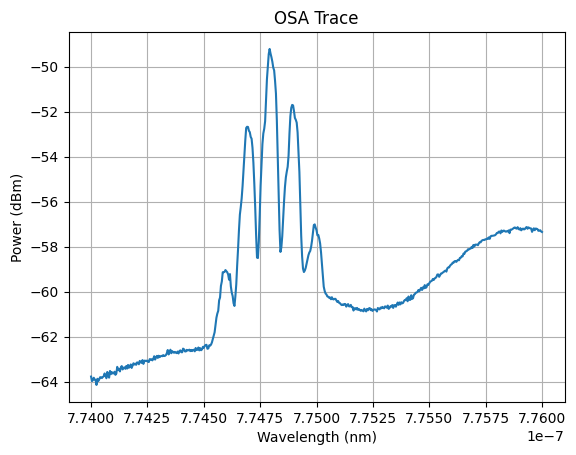

In [6]:
osa.save_trace()

In [6]:
import numpy as np
from scipy.signal import find_peaks
from numpy.polynomial.chebyshev import Chebyshev

def find_local_minima(x, y):
    """
    Find local minima in the data using scipy's find_peaks on inverted y-values.
    
    Parameters:
        x (list or array): The x-coordinates of the points (domain).
        y (list or array): The y-coordinates of the points (image).
    
    Returns:
        minima_x (array): x-values corresponding to the local minima.
        minima_y (array): y-values of the local minima.
    """
    # Invert y-values to find peaks which correspond to minima in the original data
    inverted_y = -np.array(y)
    
    # Use scipy's find_peaks to find local maxima in the inverted signal (i.e., local minima in original)
    minima_indices, _ = find_peaks(inverted_y, distance=20)

    # Get the corresponding x-values and y-values for the local minima
    minima_x = np.array(x)[minima_indices]
    minima_y = np.array(y)[minima_indices]

    return minima_x, minima_y


def fit_polynomial(x, y, order):
    """
    Fits a polynomial of a given order to the provided points.
    
    Parameters:
        x (list or array): x-coordinates of the points.
        y (list or array): y-coordinates of the points.
        order (int): The order of the polynomial to fit.

    Returns:
        p (ndarray): Polynomial coefficients, highest degree first.
        y_fit (ndarray): y-values of the fitted polynomial.
    """
    # Fit the polynomial to the data
    #p = np.polyfit(x, y, order)
    cheb_coeffs = Chebyshev.fit(x, y, order)
    
    # Generate the fitted polynomial's y-values using the coefficients
    
    return cheb_coeffs

def plot_polynomial_fit(x_orig, y_orig, x_fit, y_fit, order):
    """
    Plots the original points and the polynomial fit.
    
    Parameters:
        x (list or array): x-coordinates of the points.
        y (list or array): y-coordinates of the points.
        y_fit (list or array): y-values of the fitted polynomial.
        order (int): The order of the fitted polynomial.
    """

    plt.plot(x_orig, y_orig, color='red', label='Data Points')  # Original points
    #plt.scatter(x_opt, y_opt, color='blue', label='Opt Points')  # Original points
    plt.plot(x_fit, y_fit, color='green', label=f'Polynomial Fit (order {order})')  # Fitted polynomial
    
    plt.title(f'Polynomial Fit of Order {order}')
    plt.xlabel('wavelenght')
    plt.ylabel('power')
    plt.legend()
    plt.grid(True)
    plt.show()



def do_calibration(osa, center=775, span=2, order = 20):
    wavelength, power = perform_measurement_OSA(osa, center, span)
    x,y = find_local_minima(wavelength, power)

    # Fit polynomial and get the fitted y-values
    return wavelength, power, fit_polynomial(x, y, order)
    #plot_polynomial_fit(wavelength[50:400], power[50:400], wavelength[50:400], y_fit(wavelength[50:400]), order)
    #plt.plot(wavelength[50:400],power[50:400]- y_fit(wavelength[50:400]))
    #plt.xlabel('wavelenght')
    #plt.ylabel('dB')



In [42]:
# Load data from a CSV file into a NumPy array
def load_csv_to_numpy(filename):
    data = np.genfromtxt(filename, delimiter=',', skip_header=1)  # Assuming the CSV has a header
    return data

# Example usage
csv_file = './data/trace_data_0_7.csv'  # Replace with the path to your CSV file
data_array = load_csv_to_numpy(csv_file)
print("Data in NumPy Array:\n", data_array)

Data in NumPy Array:
 [[ 7.73700000e-07 -5.53764449e+01]
 [ 7.73704000e-07 -5.53277865e+01]
 [ 7.73708000e-07 -5.52932361e+01]
 ...
 [ 7.75692000e-07 -4.90088379e+01]
 [ 7.75696000e-07 -4.91398915e+01]
 [ 7.75700000e-07 -4.91070647e+01]]


Chebyshev fitting (highest degree): 15


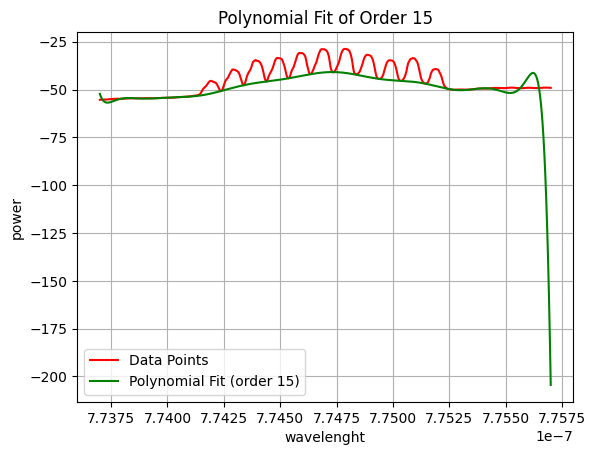

Text(0, 0.5, 'dB')

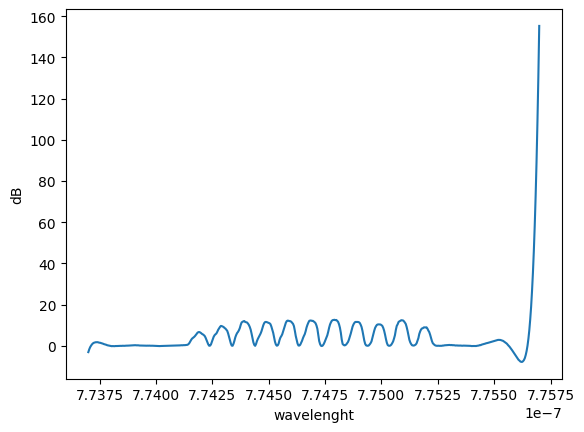

In [43]:
wavelenght, power = data_array[:,0], data_array[:,1]
x,y = find_local_minima(wavelenght, power)
# Example usage:


order = 15 # Example: fit a 2nd-degree polynomial

# Fit polynomial and get the fitted y-values
y_fit = fit_polynomial(x, y, order)

# Print the polynomial coefficients
print(f"Chebyshev fitting (highest degree): {order}")

# Plot the polynomial fit
plot_polynomial_fit(wavelenght, power, wavelenght, y_fit(wavelenght), order)
plt.plot(wavelenght,power- y_fit(wavelenght))
plt.xlabel('wavelenght')
plt.ylabel('dB')


Text(0, 0.5, 'dB')

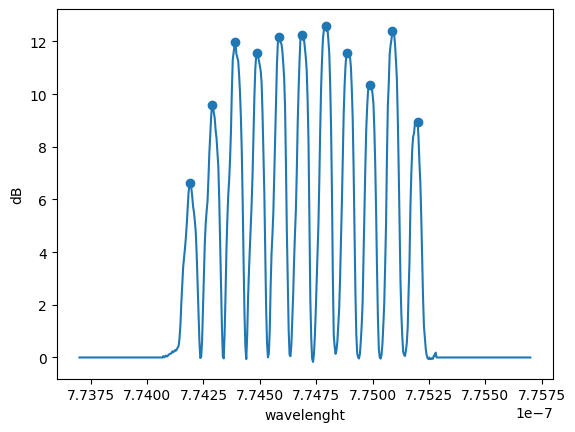

In [44]:
prominence = power - y_fit(wavelenght)
prominence = calibration.set_measurement_outside_range_to_zero(wavelenght, prominence, 7.741e-7-0.0003e-7, 7.7525e-7+0.0003e-7)
       
prominence_trim = prominence
wavelenght_trim = wavelenght
max_indices, _ = find_peaks(prominence_trim, distance=20, prominence=0.55)
max_x = np.array(wavelenght_trim)[max_indices]
max_y = np.array(prominence_trim)[max_indices]
plt.plot(wavelenght_trim,prominence_trim)
plt.scatter(max_x, max_y)
plt.xlabel('wavelenght')
plt.ylabel('dB')

In [41]:
max_x


array([7.74192e-07, 7.74288e-07, 7.74392e-07, 7.74484e-07, 7.74584e-07,
       7.74684e-07, 7.74792e-07, 7.74888e-07, 7.74988e-07, 7.75092e-07,
       7.75196e-07])

In [45]:
max_x

array([7.74192e-07, 7.74288e-07, 7.74392e-07, 7.74488e-07, 7.74584e-07,
       7.74688e-07, 7.74792e-07, 7.74888e-07, 7.74988e-07, 7.75088e-07,
       7.75200e-07])

In [46]:
max_indices

array([123, 147, 173, 197, 221, 247, 273, 297, 322, 347, 375])